# Conformal Prediction: Uncertainty Quantification and Drift Detection with $\texttt{crepes}$

This notebook was developed by Henrik Boström (bostromh@kth.se) to be used in a hands-on session at Traton, Södertälje on June 2, 2026.

$\texttt{crepes}$ may be installed by ```pip install crepes``` or ```conda install conda-forge::crepes```

Github repository: https://github.com/henrikbostrom/crepes/ 

Documentation: https://crepes.readthedocs.io/en/latest/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn # may be installed by: pip install scikit-learn

from crepes import __version__

print(f"crepes v. {__version__}")

np.random.seed(602211023)
np.set_printoptions(legacy='1.25')

crepes v. 0.9.1


## Conformal classifiers

### Importing and splitting a dataset

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

dataset = fetch_openml(name="qsar-biodeg", version=1, parser="auto")

X = dataset.data.values.astype(float)

target = dataset.target.cat.rename_categories({"1":"RB", "2":"NRB"})
y = target.values

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=1/4)

X_prop_train, X_cal, y_prop_train, y_cal = \
    train_test_split(X_train, y_train, test_size=1/3)

In [3]:
print(dataset.DESCR)

**Author**: Kamel Mansouri, Tine Ringsted, Davide Ballabio  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/QSAR+biodegradation)  
**Please cite**: Mansouri, K., Ringsted, T., Ballabio, D., Todeschini, R., Consonni, V. (2013). Quantitative Structure - Activity Relationship models for ready biodegradability of chemicals. Journal of Chemical Information and Modeling, 53, 867-878 


QSAR biodegradation Data Set 

* Abstract: 

Data set containing values for 41 attributes (molecular descriptors) used to classify 1055 chemicals into 2 classes (ready and not ready biodegradable).


* Source:

Kamel Mansouri, Tine Ringsted, Davide Ballabio (davide.ballabio '@' unimib.it), Roberto Todeschini, Viviana Consonni, Milano Chemometrics and QSAR Research Group (http://michem.disat.unimib.it/chm/), UniversitÃ  degli Studi Milano â€“ Bicocca, Milano (Italy)


* Data Set Information:

The QSAR biodegradation dataset was built in the Milano Chemometrics and QSAR Research Group (UniversitÃ  deg

In [4]:
pd.concat([dataset.data, target], axis="columns")

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V33,V34,V35,V36,V37,V38,V39,V40,V41,Class
0,3.919,2.6909,0,0,0,0,0,31.4,2,0,...,0,0,0,2.949,1.591,0,7.253,0,0,NRB
1,4.170,2.1144,0,0,0,0,0,30.8,1,1,...,0,0,0,3.315,1.967,0,7.257,0,0,NRB
2,3.932,3.2512,0,0,0,0,0,26.7,2,4,...,0,0,1,3.076,2.417,0,7.601,0,0,NRB
3,3.000,2.7098,0,0,0,0,0,20.0,0,2,...,0,0,1,3.046,5.000,0,6.690,0,0,NRB
4,4.236,3.3944,0,0,0,0,0,29.4,2,4,...,0,0,0,3.351,2.405,0,8.003,0,0,NRB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,5.431,2.8955,0,0,0,2,0,32.1,4,1,...,0,6,1,3.573,2.242,1,8.088,0,0,RB
1051,5.287,3.3732,0,0,9,0,0,35.3,0,9,...,0,3,0,3.787,3.083,3,9.278,0,0,RB
1052,4.869,1.7670,0,1,9,0,5,44.4,0,4,...,4,13,0,3.848,2.576,5,9.537,1,0,RB
1053,5.158,1.6914,2,0,36,0,9,56.1,0,0,...,1,16,0,5.808,2.055,8,11.055,0,1,RB


### Fitting and predicting with a model

In [5]:
from crepes import WrapClassifier

from sklearn.ensemble import RandomForestClassifier

rf = WrapClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=500))

rf.fit(X_prop_train, y_prop_train)

In [6]:
rf.learner.classes_

array(['NRB', 'RB'], dtype=object)

In [7]:
rf.predict_proba(X_test)

array([[0.976, 0.024],
       [0.602, 0.398],
       [0.258, 0.742],
       [0.01 , 0.99 ],
       [0.25 , 0.75 ],
       [0.774, 0.226],
       [0.91 , 0.09 ],
       [0.024, 0.976],
       [0.812, 0.188],
       [0.046, 0.954],
       [0.512, 0.488],
       [0.496, 0.504],
       [0.98 , 0.02 ],
       [0.02 , 0.98 ],
       [0.17 , 0.83 ],
       [0.75 , 0.25 ],
       [0.058, 0.942],
       [0.076, 0.924],
       [0.338, 0.662],
       [0.126, 0.874],
       [0.538, 0.462],
       [0.126, 0.874],
       [0.018, 0.982],
       [0.752, 0.248],
       [0.72 , 0.28 ],
       [0.26 , 0.74 ],
       [0.254, 0.746],
       [0.514, 0.486],
       [0.904, 0.096],
       [0.168, 0.832],
       [0.47 , 0.53 ],
       [0.022, 0.978],
       [0.32 , 0.68 ],
       [0.894, 0.106],
       [0.098, 0.902],
       [0.57 , 0.43 ],
       [0.002, 0.998],
       [0.06 , 0.94 ],
       [0.548, 0.452],
       [0.914, 0.086],
       [0.264, 0.736],
       [0.488, 0.512],
       [0.914, 0.086],
       [0.9

### Calibrating a conformal classifier

In [8]:
rf.calibrate(X_cal, y_cal)

WrapClassifier(learner=RandomForestClassifier(n_estimators=500, n_jobs=-1), calibrated=True, predictor=ConformalClassifier(fitted=True, mondrian=False))

### Making predictions with a conformal classifier

In [9]:
rf.predict_p(X_test)

array([[0.86591307, 0.009655  ],
       [0.21245622, 0.11287193],
       [0.05225292, 0.33847531],
       [0.00543339, 0.94615489],
       [0.04667822, 0.34295542],
       [0.36251037, 0.03949246],
       [0.63360608, 0.01348513],
       [0.01032871, 0.86814342],
       [0.39639323, 0.03220911],
       [0.01350645, 0.781198  ],
       [0.1842223 , 0.17222362],
       [0.1816886 , 0.18284148],
       [0.88471058, 0.00959333],
       [0.00973939, 0.90069451],
       [0.02661264, 0.43200106],
       [0.34048452, 0.04866524],
       [0.01356317, 0.74583975],
       [0.01333497, 0.69212354],
       [0.10177012, 0.25795805],
       [0.02222772, 0.51850605],
       [0.18827224, 0.14742417],
       [0.02064685, 0.51507865],
       [0.00872323, 0.90903078],
       [0.34211292, 0.04554309],
       [0.31897433, 0.06260736],
       [0.05235068, 0.333479  ],
       [0.04570096, 0.34304774],
       [0.18435562, 0.17045744],
       [0.60786301, 0.01203253],
       [0.02955088, 0.44006047],
       [0.

In [10]:
rf.predict_set(X_test)

[['NRB'],
 ['NRB', 'RB'],
 ['RB'],
 ['RB'],
 ['RB'],
 ['NRB'],
 ['NRB'],
 ['RB'],
 ['NRB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB'],
 ['RB'],
 ['RB'],
 ['NRB'],
 ['RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['RB'],
 ['NRB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB'],
 ['RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB'],
 ['RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB'],
 ['NRB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB'],
 ['NRB', 'RB'],
 ['NRB'],
 ['RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['RB'],
 ['NRB'],
 ['NRB'],
 ['NRB'],
 ['NRB'],
 ['RB'],
 ['NRB'],
 ['RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['RB'],
 ['NRB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['RB'],
 ['RB'],
 ['RB'],
 ['NRB'],
 ['RB'],
 ['NRB'],
 ['NRB', 'RB'],
 ['NRB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB

In [11]:
rf.predict_set(X_test, confidence=0.99)

[['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['NRB', 'RB'],
 ['N

### Evaluating a conformal classifier

In [12]:
rf.evaluate(X_test, y_test, confidence=0.9) 

{'error': 0.08712121212121215,
 'avg_c': 1.1931818181818181,
 'one_c': 0.8068181818181818,
 'empty': 0.0,
 'ks_test': 0.2871130437312297,
 'time_fit': 2.1457672119140625e-06,
 'time_evaluate': 0.10008025169372559}

In [13]:
rf.evaluate(X_test, y_test, confidence=0.99) 

{'error': 0.0,
 'avg_c': 1.8484848484848484,
 'one_c': 0.15151515151515152,
 'empty': 0.0,
 'ks_test': 0.31526037339487745,
 'time_fit': 2.1457672119140625e-06,
 'time_evaluate': 0.10972833633422852}

## Conformal regressors

### Importing and splitting a dataset

In [14]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

dataset = fetch_openml(name="house_sales", version=3, parser="auto")

df = dataset.data.drop(["date_year", "date_month", "date_day"], axis="columns")

X = dataset.data.values.astype(float)
y = dataset.target.values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)
X_prop_train, X_cal, y_prop_train, y_cal = train_test_split(X_train, y_train,
                                                            test_size=0.25)

In [15]:
print(dataset.DESCR)

Date converted to year/mo/day numerics.This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015.

It contains 19 house features plus the price and the id columns, along with 21613 observations.
It's a great dataset for evaluating simple regression models.

Downloaded from openml.org.


In [16]:
pd.concat([df, dataset.target], axis="columns")

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,221900.0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,538000.0
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,180000.0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,604000.0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,510000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509,360000.0
21609,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200,400000.0
21610,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007,402101.0
21611,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287,400000.0


### Fitting and predicting with a model

In [17]:
from sklearn.ensemble import RandomForestRegressor
from crepes import WrapRegressor

rf = WrapRegressor(RandomForestRegressor(n_jobs=-1, n_estimators=500, oob_score=True))
rf.fit(X_prop_train, y_prop_train)

In [18]:
y_hat = rf.predict(X_test)

print(f"corr. coeff. = {np.corrcoef(y_hat, y_test)[0][1]:.3f}")

corr. coeff. = 0.926


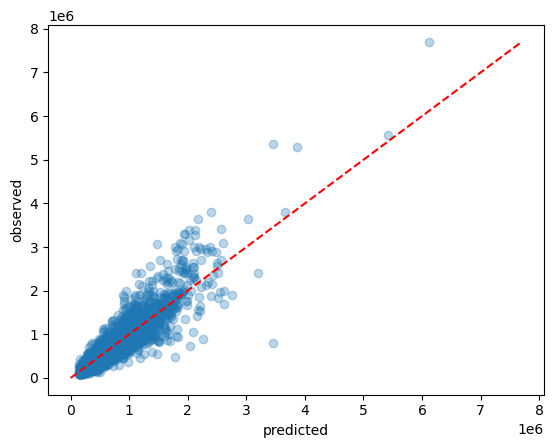

In [19]:
import matplotlib.pyplot as plt

plt.xlabel("predicted")
plt.ylabel("observed")
plt.scatter(y_hat, y_test, alpha=0.3)
plt.plot([0,np.max(y_test)],[0,np.max(y_test)], "--", c="red")
#plt.savefig("predicted_vs_observed", dpi=400)
plt.show()

### Standard conformal regressor

In [20]:
rf.calibrate(X_cal, y_cal)
intervals = rf.predict_int(X_test, confidence=0.9)
display(intervals)

array([[ 253048.226,  558818.89 ],
       [1134309.448, 1440080.112],
       [ 444294.302,  750064.966],
       ...,
       [ 231100.464,  536871.128],
       [ 580681.29 ,  886451.954],
       [ 267447.824,  573218.488]])

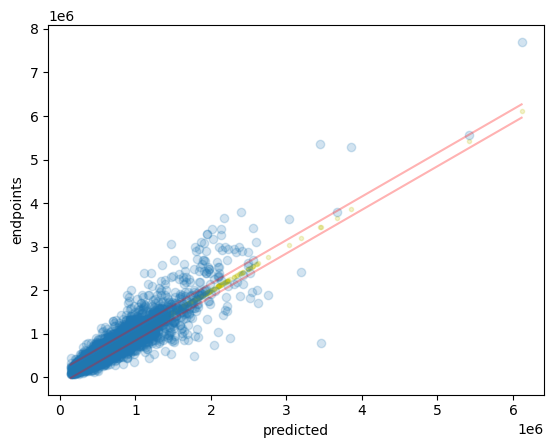

In [21]:
index = np.argsort(y_hat)

plt.xlabel("predicted")
plt.ylabel("endpoints")
plt.scatter(y_hat, y_hat, color="y", marker=".", alpha=0.2)
plt.scatter(y_hat[index], y_test[index], alpha=0.2)
plt.plot(y_hat[index], intervals[index,0], c="red", alpha=0.3)
plt.plot(y_hat[index], intervals[index,1], c="red", alpha=0.3)
#plt.savefig("standard_intervals", dpi=400)
plt.show()

### Difficulty estimators

In [22]:
beta = 0.01

In [23]:
from crepes.extras import DifficultyEstimator

de_knn = DifficultyEstimator()
de_knn.fit(X=X_prop_train, 
           k=5,
           scaler=True,
           y=y_prop_train,
           beta=beta) 

DifficultyEstimator(fitted=True, type=knn, k=5, target=labels, scaler=True, beta=0.01, oob=False)

In [24]:
difficulties = de_knn.apply(X_test)
display(difficulties)

array([0.09913407, 0.25643292, 0.08583337, ..., 0.08516516, 0.09439547,
       0.13583728])

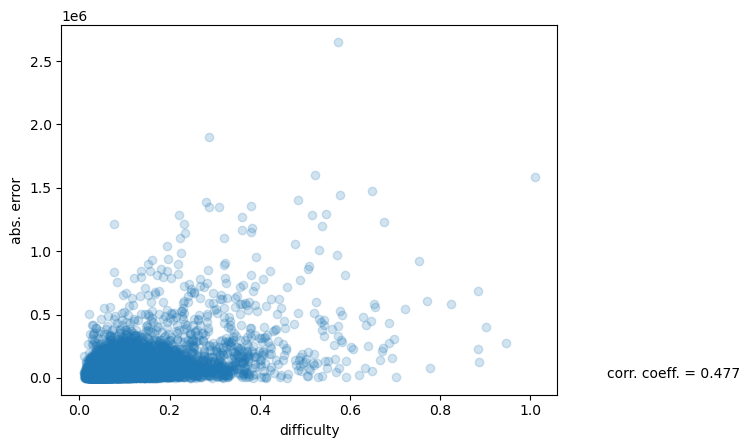

In [25]:
plt.xlabel("difficulty")
plt.ylabel("abs. error")
plt.scatter(difficulties, np.abs(y_hat-y_test), alpha=0.2)
plt.text(1.17, 3.5, f"corr. coeff. = {np.corrcoef(difficulties, np.abs(y_hat-y_test))[0][1]:.3f}")
#plt.savefig("knn_difficulties", dpi=400)
plt.show()

In [26]:
de_var = DifficultyEstimator()
de_var.fit(X=X_prop_train,
           learner=rf.learner, 
           scaler=True,
           beta=beta)

DifficultyEstimator(fitted=True, type=variance, scaler=True, beta=0.01, oob=False)

In [27]:
difficulties = de_var.apply(X_test)
display(difficulties)

array([0.01421697, 0.03717361, 0.01425994, ..., 0.01125052, 0.01626403,
       0.01248813])

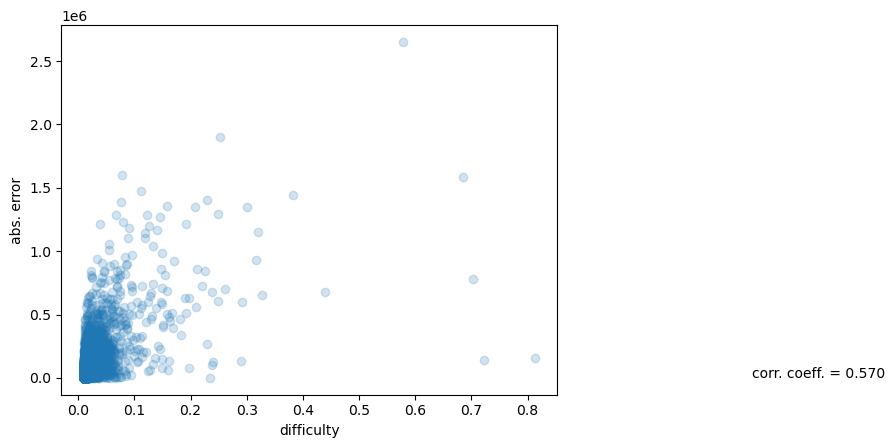

In [28]:
plt.xlabel("difficulty")
plt.ylabel("abs. error")
plt.scatter(difficulties, np.abs(y_hat-y_test), alpha=0.2)
plt.text(1.2, 3.5, f"corr. coeff. = {np.corrcoef(difficulties, np.abs(y_hat-y_test))[0][1]:.3f}")
#plt.savefig("variance_difficulties", dpi=400)
plt.show()

In [29]:
de_pred = DifficultyEstimator()
de_pred.fit(X=X_prop_train,
           f=rf.predict, 
           scaler=True,
           beta=beta)

DifficultyEstimator(fitted=True)

In [30]:
difficulties = de_pred.apply(X_test)
display(difficulties)

array([0.05678014, 0.20343785, 0.08860692, ..., 0.05312764, 0.11130417,
       0.05917649])

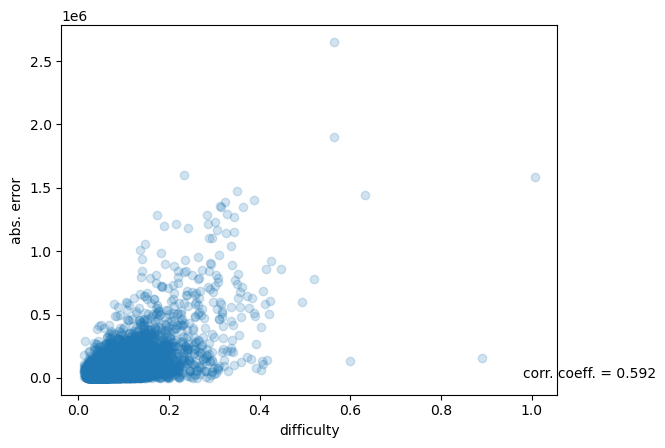

In [31]:
plt.xlabel("difficulty")
plt.ylabel("abs. error")
plt.scatter(difficulties, np.abs(y_hat-y_test), alpha=0.2)
plt.text(0.98, 3.5, f"corr. coeff. = {np.corrcoef(difficulties, np.abs(y_hat-y_test))[0][1]:.3f}")
#plt.savefig("model_difficulties", dpi=400)
plt.show()

In [32]:
diff_y = np.abs(y_prop_train-rf.learner.oob_prediction_)
diff_model = RandomForestRegressor(n_jobs=-1, n_estimators=500)
diff_model.fit(X_prop_train, diff_y)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
de_mod = DifficultyEstimator()
de_mod.fit(X=X_prop_train,
           f=diff_model.predict, 
           scaler=True,
           beta=beta)

DifficultyEstimator(fitted=True)

In [34]:
difficulties = de_mod.apply(X_test)
display(difficulties)

array([0.03958333, 0.1090371 , 0.03069388, ..., 0.0230251 , 0.06050444,
       0.03446444])

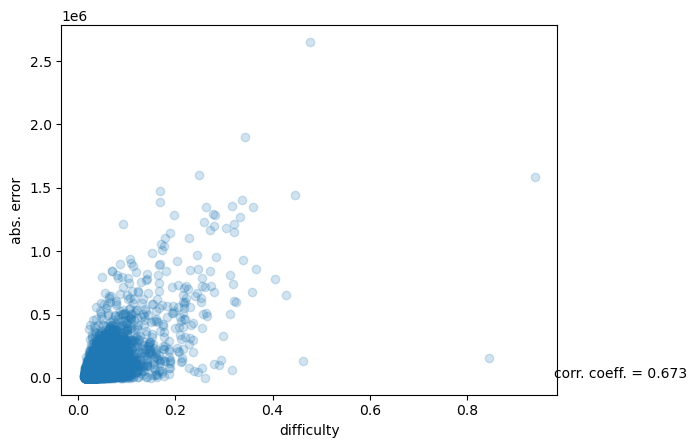

In [35]:
plt.xlabel("difficulty")
plt.ylabel("abs. error")
plt.scatter(difficulties, np.abs(y_hat-y_test), alpha=0.2)
plt.text(0.98, 3.5, f"corr. coeff. = {np.corrcoef(difficulties, np.abs(y_hat-y_test))[0][1]:.3f}")
#plt.savefig("model_difficulties", dpi=400)
plt.show()

### Normalized conformal regressor

In [36]:
rf_norm = WrapRegressor(rf.learner)
rf_norm.calibrate(X_cal, y_cal, de=de_mod)

WrapRegressor(learner=RandomForestRegressor(n_estimators=500, n_jobs=-1, oob_score=True), calibrated=True, predictor=ConformalRegressor(fitted=True, normalized=True, mondrian=False))

In [37]:
intervals = rf_norm.predict_int(X_test, confidence=0.9)
display(intervals)

array([[ 261938.53522924,  549928.58077076],
       [ 890542.99317602, 1683846.56682398],
       [ 485522.40287868,  708836.86512132],
       ...,
       [ 300225.79219511,  467745.79980489],
       [ 513465.43804665,  953667.80595335],
       [ 294959.489418  ,  545706.822582  ]])

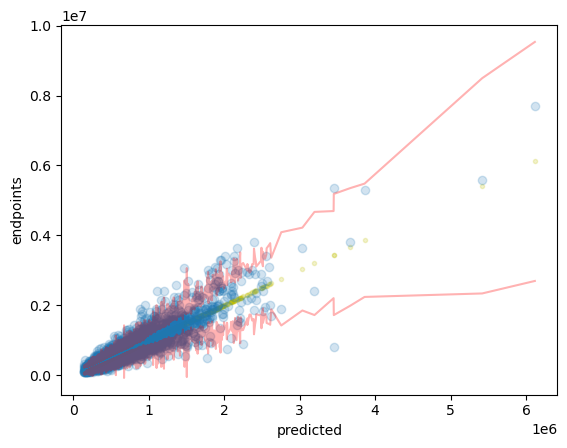

In [38]:
index = np.argsort(y_hat)

plt.xlabel("predicted")
plt.ylabel("endpoints")
plt.scatter(y_hat, y_hat, color="y", marker=".", alpha=0.2)
plt.scatter(y_hat[index], y_test[index], alpha=0.2)
plt.plot(y_hat[index], intervals[index,0], c="red", alpha=0.3)
plt.plot(y_hat[index], intervals[index,1], c="red", alpha=0.3)
#plt.savefig("norm_knn_intervals", dpi=400)
plt.show()

### Mondrian conformal regressor

In [39]:
from crepes.extras import MondrianCategorizer

mc_knn = MondrianCategorizer()
mc_knn.fit(X_cal, de=de_mod, no_bins=20)

rf_mond_knn = WrapRegressor(rf.learner)
rf_mond_knn.calibrate(X_cal, y_cal, mc=mc_knn)

WrapRegressor(learner=RandomForestRegressor(n_estimators=500, n_jobs=-1, oob_score=True), calibrated=True, predictor=ConformalRegressor(fitted=True, normalized=False, mondrian=True))

In [40]:
mond_intervals = rf_mond_knn.predict_int(X_test, confidence=0.9)
display(mond_intervals)

array([[ 273983.686,  537883.43 ],
       [ 481474.108, 2092915.452],
       [ 497906.   ,  696453.268],
       ...,
       [ 315426.218,  452545.374],
       [ 465859.712, 1001273.532],
       [ 276492.456,  564173.856]])

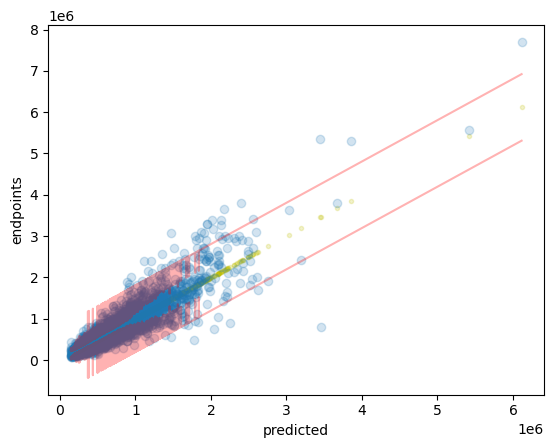

In [41]:
index = np.argsort(y_hat)

plt.xlabel("predicted")
plt.ylabel("endpoints")
plt.scatter(y_hat, y_hat, color="y", marker=".", alpha=0.2)
plt.scatter(y_hat[index], y_test[index], alpha=0.2)
plt.plot(y_hat[index], mond_intervals[index,0], c="red", alpha=0.3)
plt.plot(y_hat[index], mond_intervals[index,1], c="red", alpha=0.3)
#plt.savefig("mond_knn_intervals", dpi=400)
plt.show()

### Comparison of conformal regressors

In [42]:
coverages = []
mean_sizes = []
median_sizes = []

variants = [("std", None), 
            ("norm_knn", de_knn), 
            ("norm_var", de_var),
            ("norm_pred", de_pred),
            ("norm_mod", de_mod)]

prediction_intervals = {}
    
for name, de in variants:
    rf_norm = WrapRegressor(rf.learner)
    rf_norm.calibrate(X_cal, y_cal, de=de)
    intervals = rf_norm.predict_int(X_test, confidence=0.9)
    prediction_intervals[name] = intervals

prediction_intervals["mond_mod"] = mond_intervals

for name in prediction_intervals.keys():
    intervals = prediction_intervals[name]
    coverages.append(np.sum([1 if (y_test[i]>=intervals[i,0] and 
                                   y_test[i]<=intervals[i,1]) else 0 
                            for i in range(len(y_test))])/len(y_test))
    mean_sizes.append((intervals[:,1]-intervals[:,0]).mean())
    median_sizes.append(np.median((intervals[:,1]-intervals[:,0])))

pred_int_df = pd.DataFrame({"Coverage":coverages, 
                            "Mean size":mean_sizes, 
                            "Median size":median_sizes}, 
                           index=list(prediction_intervals.keys()))

pred_int_df.loc["Mean"] = [pred_int_df["Coverage"].mean(), 
                           pred_int_df["Mean size"].mean(),
                           pred_int_df["Median size"].mean()]

In [43]:
pred_int_df["Coverage"] = pred_int_df["Coverage"].round(4)
pred_int_df["Mean size"] = pred_int_df["Mean size"].round(1)
pred_int_df["Median size"] = pred_int_df["Median size"].round(1)
display(pred_int_df)

,Coverage,Mean size,Median size
std,0.8928,305770.7,305770.7
norm_knn,0.8924,362308.5,271122.5
norm_var,0.8954,301553.6,216689.9
norm_pred,0.8913,307684.8,257821.1
norm_mod,0.8962,285708.8,223496.5
mond_mod,0.9011,317242.7,200146.9
Mean,0.8949,313378.2,245841.2


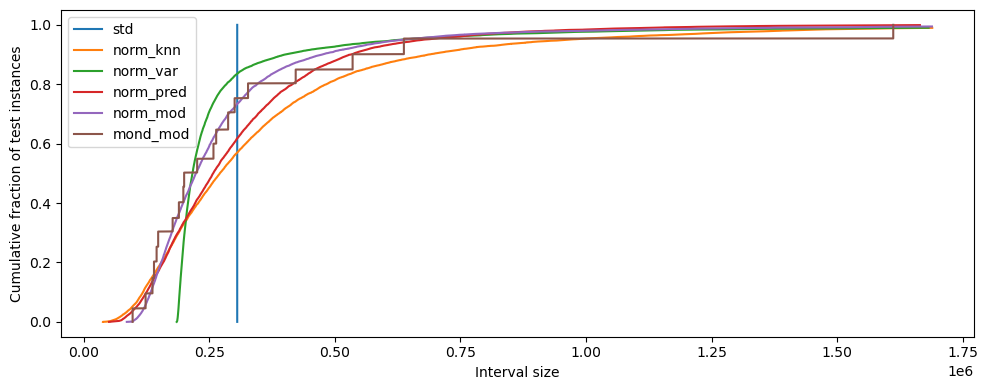

In [44]:
sizes = {name : prediction_intervals[name][:,1] - prediction_intervals[name][:,0] for name in prediction_intervals}

def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, len(x) + 1) / len(x)
    return xs, ys

x_max = np.percentile(
    np.concatenate([sizes[name] for name in sizes]), 99) * 1.05

fig, ax = plt.subplots(figsize=(10, 4))

for name in sizes:
    xs, ys = ecdf(sizes[name])
    ax.plot(xs[xs <= x_max], ys[xs <= x_max], label=name, linewidth=1.5)

ax.set_xlabel('Interval size')
ax.set_ylabel('Cumulative fraction of test instances')
ax.legend()
plt.tight_layout()

#plt.savefig(fig_file, dpi=400, bbox_inches="tight")
plt.show()

## Conformal predictive systems

### Mondrian conformal predictive systems

In [45]:
mc_pred = MondrianCategorizer()
mc_pred.fit(X_cal, f=rf.predict, no_bins=5)

cps_mond = WrapRegressor(rf.learner)
cps_mond.calibrate(X_cal, y_cal, mc=mc_pred, cps=True)
cps_mond.predict_int(X_test, confidence=0.9)

array([[ 313608.062,  490352.496],
       [ 965026.52 , 1793916.044],
       [ 460305.178,  741730.19 ],
       ...,
       [ 291660.3  ,  468404.734],
       [ 411398.362, 1240287.886],
       [ 303335.888,  545946.378]])

In [46]:
cps_mond.predict_int(X_test, confidence=0.9)

array([[ 313608.062,  490352.496],
       [ 965026.52 , 1793916.044],
       [ 460305.178,  741730.19 ],
       ...,
       [ 291660.3  ,  468404.734],
       [ 411398.362, 1240287.886],
       [ 303335.888,  545946.378]])

In [47]:
intervals = cps_mond.predict_int(X_test, confidence=0.9)

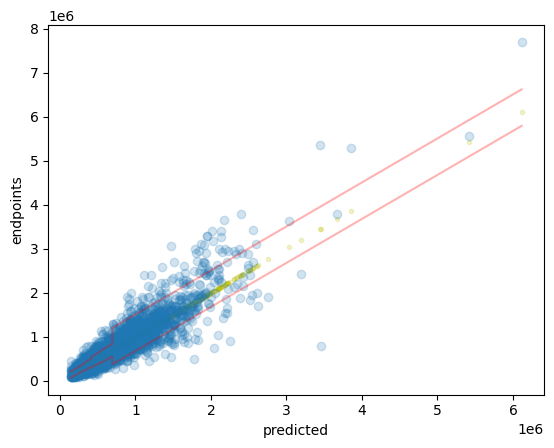

In [48]:
index = np.argsort(y_hat)

plt.xlabel("predicted")
plt.ylabel("endpoints")
plt.scatter(y_hat, y_hat, color="y", marker=".", alpha=0.2)
plt.scatter(y_hat[index], y_test[index], alpha=0.2)
plt.plot(y_hat[index], intervals[index,0], c="red", alpha=0.3)
plt.plot(y_hat[index], intervals[index,1], c="red", alpha=0.3)
#plt.savefig("cps_mond_intervals", dpi=400)
plt.show()

### Normalized mondrian conformal predictive systems

In [49]:
cps_mond_norm = WrapRegressor(rf.learner)

cps_mond_norm.calibrate(X_cal, y_cal, mc=mc_pred, de=de_var, cps=True, seed=123)
cps_mond_norm.predict_int(X_test, confidence=0.9)

array([[ 285895.13009831,  508631.49934101],
       [ 929612.59968928, 1835115.58764786],
       [ 463964.09605943,  740991.59387583],
       ...,
       [ 288994.00421639,  465255.28303844],
       [ 577118.86743615,  973290.48061296],
       [ 305493.13031533,  543498.5112293 ]])

In [50]:
intervals = cps_mond_norm.predict_int(X_test, confidence=0.9)

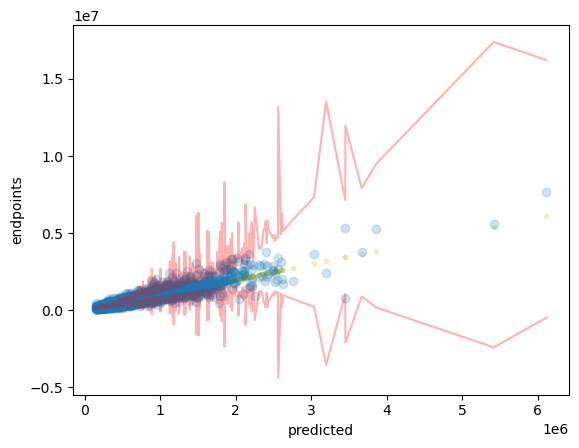

In [51]:
index = np.argsort(y_hat)

plt.xlabel("predicted")
plt.ylabel("endpoints")
plt.scatter(y_hat, y_hat, color="y", marker=".", alpha=0.2)
plt.scatter(y_hat[index], y_test[index], alpha=0.2)
plt.plot(y_hat[index], intervals[index,0], c="red", alpha=0.3)
plt.plot(y_hat[index], intervals[index,1], c="red", alpha=0.3)
#plt.savefig("cps_mond_norm_intervals", dpi=400)
plt.show()

In [52]:
upper_bounds = cps_mond_norm.predict_cps(X_test, higher_percentiles=[90,95,99])
display(upper_bounds)

array([[ 481139.35856861,  508631.49934101,  585243.6673552 ],
       [1643918.95552022, 1835115.58764786, 2107945.34639951],
       [ 701039.45223292,  740991.59387583,  862551.74263911],
       ...,
       [ 443499.51900864,  465255.28303844,  525881.92768306],
       [ 889638.98614937,  973290.48061296, 1092657.73514953],
       [ 506548.34643372,  543498.5112293 ,  601617.35963156]])

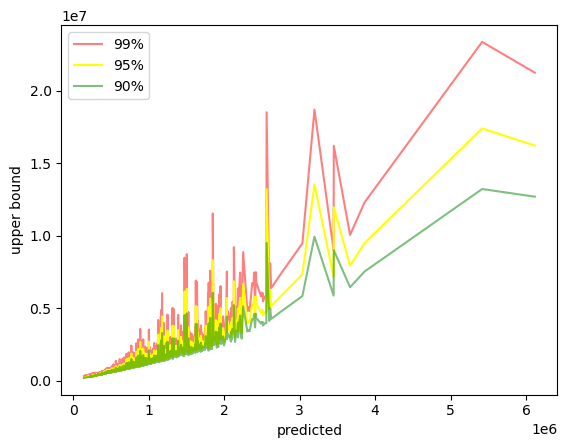

In [53]:
index = np.argsort(y_hat)

plt.xlabel("predicted")
plt.ylabel("upper bound")
plt.plot(y_hat[index], upper_bounds[index,2], c="red", alpha=0.5, label="99%")
plt.plot(y_hat[index], upper_bounds[index,1], c="yellow", alpha=0.99, label="95%")
plt.plot(y_hat[index], upper_bounds[index,0], c="green", alpha=0.5, label="90%")
plt.legend()
#plt.savefig("cps_upper_bounds", dpi=400)
plt.show()

### Obtain p-values given a threshold

In [54]:
cps_mond_norm.predict_cps(X_test, y=400_000)

array([0.45969772, 0.00237295, 0.00966146, ..., 0.64197095, 0.00401601,
       0.41071475])

In [55]:
thresholds = np.arange(0,np.median(y_test)*1.1,np.median(y_test)*1.1/10)
fractions = np.zeros(len(thresholds))
proportions = np.zeros(len(thresholds))

for i,t in enumerate(thresholds):
    p_values = cps_mond_norm.predict_cps(X_test, y=t)
    fractions[i] = 1-np.sum(p_values < 0.05)/ len(y_test)
    proportions[i] = np.sum(y_test <= t)/ len(y_test)

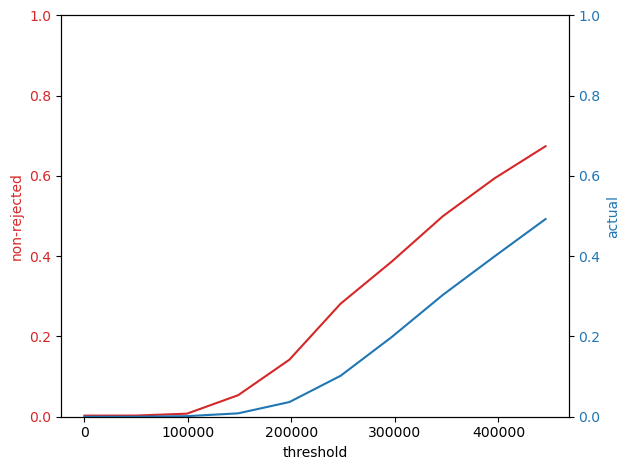

In [56]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('threshold')
ax1.set_ylabel('non-rejected', color=color)
ax1.plot(thresholds, fractions, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim([0,1])

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('actual', color=color)  # we already handled the x-label with ax1
ax2.plot(thresholds, proportions, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([0,1])
#plt.grid(which="major", axis="both")

fig.tight_layout()  # otherwise the right y-label is slightly clipped
#plt.savefig("rejected_vs_actual", dpi=400)
plt.show()

### Evaluating conformal predictive systems

In [57]:
cps_mond_norm.evaluate(X_test, y_test, confidence=0.95)

{'error': 0.04876468955306745,
 'eff_mean': 421232.821759364,
 'eff_med': 281575.68192593986,
 'time_fit': 0.0006392002105712891,
 'ks_test': 0.4686993465906698,
 'time_evaluate': 0.12850093841552734}

### Obtaining conformal predictive distributions

In [58]:
cpds = cps_mond_norm.predict_cps(X_test, return_cpds=True)

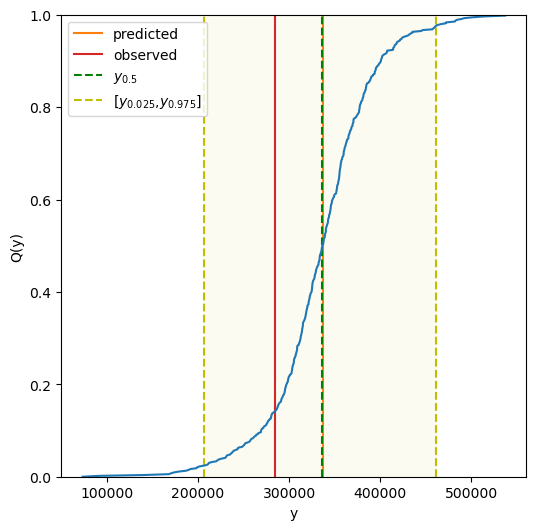

In [59]:
test_index = np.random.randint(len(X_test)) # A test object is randomly selected
cpd = cpds[test_index]

p = np.array([i/len(cpd) for i in range(len(cpd))])

lower_index = np.where(p<=0.025)[0][-1]
mid_index = np.where(p>=0.50)[0][0]
upper_index = np.where(p>=0.975)[0][0]

low_percentile = cpd[lower_index]
median = cpd[mid_index]
high_percentile = cpd[upper_index]

plt.figure(figsize=(6,6))

y_hat = rf.predict(X_test[test_index][None,:])

plt.plot([y_hat,y_hat],[0,1], color="tab:orange")
plt.plot([y_test[test_index],y_test[test_index]],[0,1], color="tab:red")
plt.xlabel("y")
plt.ylabel("Q(y)")
plt.ylim(0,1)

plt.plot([median,median],[0,1],"g--")
plt.plot([low_percentile,low_percentile],[0,1],"y--")
plt.legend(["predicted","observed","$y_{0.5}$","[$y_{0.025}$,$y_{0.975}$]"])
plt.plot([high_percentile,high_percentile],[0,1],"y--")
plt.plot(cpd,p, color="tab:blue")
rectangle = plt.Rectangle((low_percentile,0),
                          abs(high_percentile-low_percentile),1, color="y", 
                          alpha=0.05)
plt.gca().add_patch(rectangle)
#plt.savefig("cpd",dpi=400)    
plt.show()

## Conformal test martingales

### A test case

You may try out different distributions below from which observations are sampled before and after some chosen point in time.

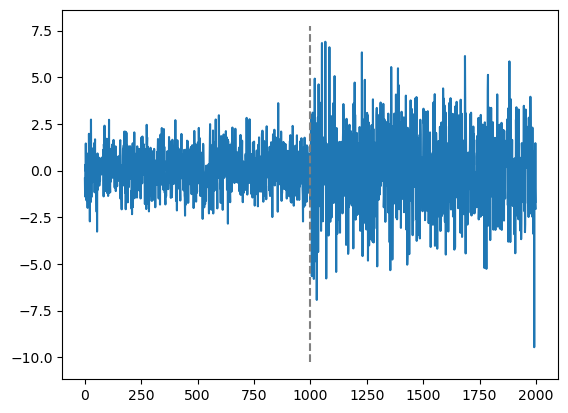

In [60]:
np.random.seed(2026)

no_alphas_1 = 1000
mean_1 = 0
std_1 = 1

alphas_1 = std_1 * np.random.randn(no_alphas_1) + mean_1

no_alphas_2 = 1000
mean_2 = 0
std_2 = 2

alphas_2 = std_2 * np.random.randn(no_alphas_2) + mean_2

alphas = np.hstack([alphas_1, alphas_2])

plt.plot(alphas)

ymin, ymax = plt.axis()[2:]
plt.plot([no_alphas_1, no_alphas_1], [ymin, ymax], linestyle='dashed', c="grey")
plt.show()

In [61]:
from crepes.martingales import semi_online_p_values

p_values = semi_online_p_values(alphas)

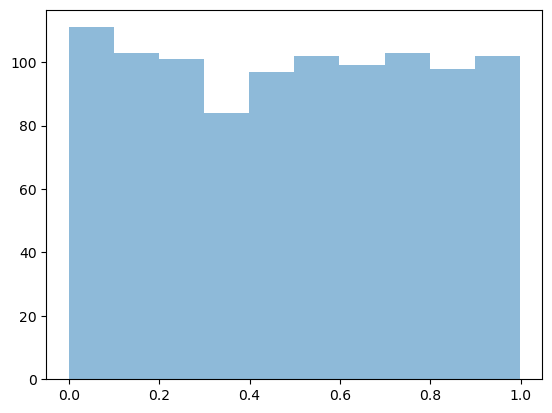

In [62]:
plt.hist(p_values[:no_alphas_1], 10, alpha=0.5)
plt.show()

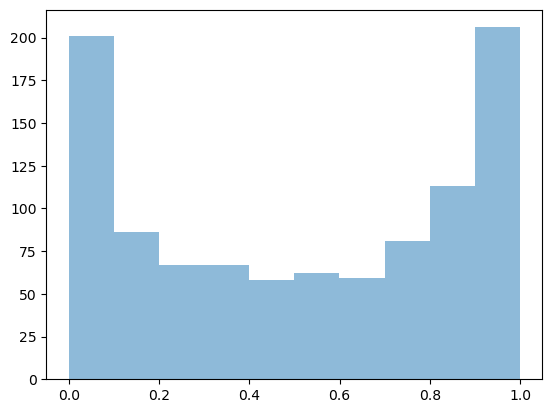

In [63]:
plt.hist(p_values[no_alphas_1:], 10, alpha=0.5)
plt.show()

In [64]:
threshold = 100 # The probability of getting a false alarm is bounded by 1/threshold

# The function below is just for plotting the results

from matplotlib.colors import TABLEAU_COLORS as colors
colors = list(colors.keys())

def plot_martingales(all_martingales, no_alphas_1=None):
    plt.yscale("log")
    plt.ylim(1e-5, 1e5)
    ymin, ymax = plt.axis()[2:]    
    early = []
    correct = []
    for i, label in enumerate(all_martingales):
        martingales = all_martingales[label]
        plt.plot(np.arange(len(martingales)), martingales, label=label, c=colors[i])
        too_large = np.argwhere(martingales > threshold)
        if len(too_large) > 0:
            drift_index = too_large[0,0]
            if no_alphas_1 is not None:
                if drift_index >= no_alphas_1:
                    correct.append((drift_index, label))
                else:
                    early.append((drift_index, label))
            plt.plot([drift_index, drift_index], [ymin, ymax], linestyle='dotted', label="_", c=colors[i])
    plt.legend()
    if no_alphas_1 is not None:
        plt.plot([no_alphas_1, no_alphas_1], [ymin, ymax], linestyle='dashed', c="grey")
    plt.show()
    if len(early) > 0:
        print("Too early:")
        for i, label in sorted(early):
            print(f"{i} : \t {label}")
        print("")
    if len(correct) > 0:
        print("Correct:")
        for i, label in sorted(correct):
            print(f"{i} : \t {label}")
        print("")

### Simple Jumper

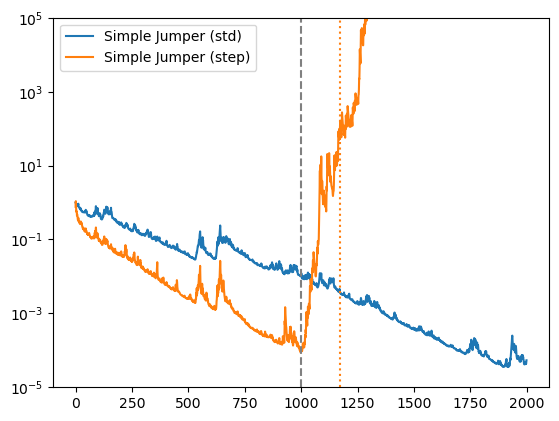

Correct:
1170 : 	 Simple Jumper (step)



In [65]:
from crepes.martingales import SimpleJumper, StepBettingFunction

martingales_simple_jumper = {
    "Simple Jumper (std)" : SimpleJumper().apply(p_values),
    "Simple Jumper (step)" : SimpleJumper(bf = StepBettingFunction()).apply(p_values),
}

plot_martingales(martingales_simple_jumper, no_alphas_1)

### Sleeper/Stayer

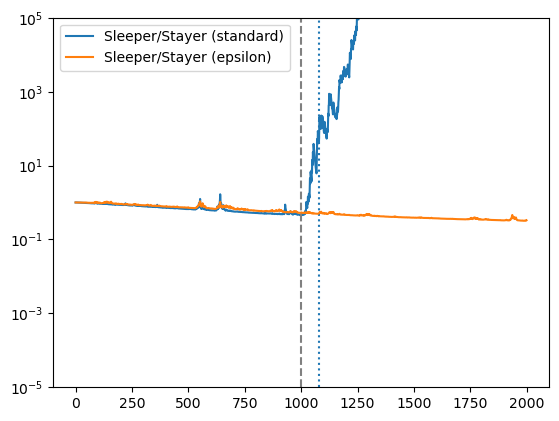

Correct:
1081 : 	 Sleeper/Stayer (standard)



In [66]:
from crepes.martingales import SleeperStayer, EpsilonBettingFunction

martingales_sleeper_stayer = {
    "Sleeper/Stayer (standard)" : SleeperStayer().apply(p_values),
    "Sleeper/Stayer (epsilon)" : SleeperStayer(bf = EpsilonBettingFunction()).apply(p_values),
}

plot_martingales(martingales_sleeper_stayer, no_alphas_1)

### Sleeper/Drifter

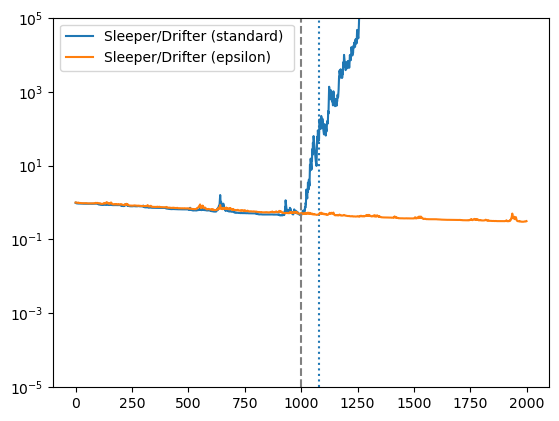

Correct:
1081 : 	 Sleeper/Drifter (standard) 



In [67]:
from crepes.martingales import SleeperDrifter

martingales_sleeper_drifter = {
    "Sleeper/Drifter (standard) " : SleeperDrifter().apply(p_values),
    "Sleeper/Drifter (epsilon)" : SleeperDrifter(bf = EpsilonBettingFunction()).apply(p_values),
}

plot_martingales(martingales_sleeper_drifter, no_alphas_1)

### Sorting house pricing

In [68]:
dataset = fetch_openml(name="house_sales", version=3, parser="auto")

sorted_index = dataset.data.sort_values(["date_year", "date_month", "date_day"]).index

X = dataset.data.loc[sorted_index].drop(["date_year", "date_month", "date_day"], axis="columns").values.astype(float)

y = dataset.target.loc[sorted_index].values.astype(float)

cal_start = 14000
test_start = 15000

X_train = X[:cal_start]
y_train = y[:cal_start]

X_cal = X[cal_start:test_start]
y_cal = y[cal_start:test_start]

X_test = X[test_start:]
y_test = y[test_start:]

### Semi-online conformal predictive systems

In [69]:
rf = WrapRegressor(RandomForestRegressor(n_jobs=-1, n_estimators=100))
rf.fit(X_train, y_train)
rf.calibrate(X_cal, y_cal, cps=True)
p_values = rf.predict_p(X_test, y_test, online=True)

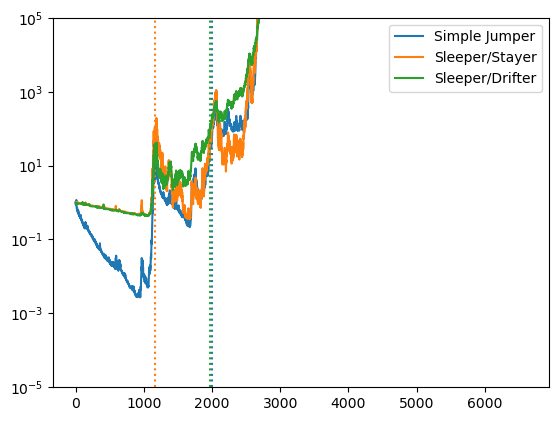

In [70]:
martingales = {
    "Simple Jumper" : SimpleJumper().apply(p_values),
    "Sleeper/Stayer" : SleeperStayer().apply(p_values),
    "Sleeper/Drifter" : SleeperDrifter().apply(p_values),
}

plot_martingales(martingales)

### Detecting drift based on predictions only

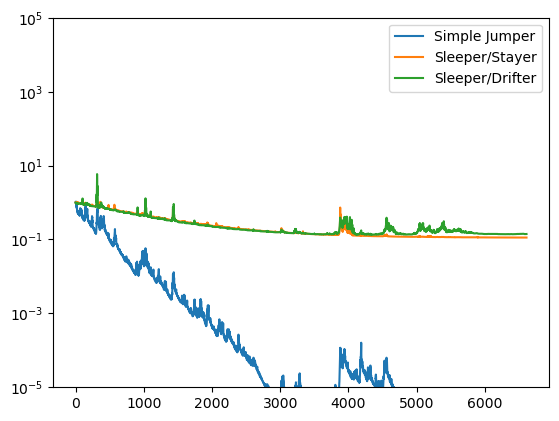

In [71]:
predictions = rf.predict(X_test)
p_values = semi_online_p_values(predictions)

martingales = {
    "Simple Jumper" : SimpleJumper().apply(p_values),
    "Sleeper/Stayer" : SleeperStayer().apply(p_values),
    "Sleeper/Drifter" : SleeperDrifter().apply(p_values),
}

plot_martingales(martingales)

### Detecting drift based on targets only

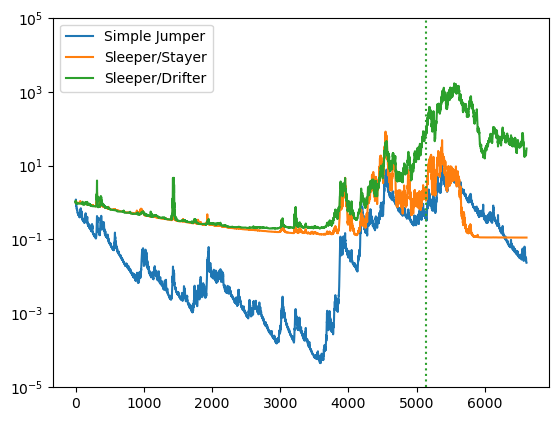

In [72]:
p_values = semi_online_p_values(y_test)

martingales = {
    "Simple Jumper" : SimpleJumper().apply(p_values),
    "Sleeper/Stayer" : SleeperStayer().apply(p_values),
    "Sleeper/Drifter" : SleeperDrifter().apply(p_values),
}

plot_martingales(martingales)